<p style="font-family:Bookman Old Style;font-size:27px; text-align:center">Low-pass filter (LPF)</p>

<div style="margin:0 130px 0 30px;text-align:justify"><p style="font-family:Source Sans Pro;font-size:20px">This filter is designed to allow only low-frequency components from the image's frequency representation (derived using the Discrete Fourier Transform, or DFT) while blocking all high frequencies beyond a specified threshold. By applying the inverse DFT, the image is reconstructed. Since high-frequency elements are associated with edges, details, and noise, the low-pass filter (LPF) effectively removes these components. The upcoming sections will explore how to implement an LPF using various functions from the numpy, scipy, and scikit-image libraries, as well as how an LPF affects an image.<br><br>In particular, the fft2() function from the numpy fft module can perform a Fast Fourier Transform on an image. Additionally, the scipy ndimage module offers several functions for applying LPFs in the frequency domain. The next section will illustrate the use of one such filter, called fourier_gaussian(), through an example.</p></div>

<p style="font-family:Bookman Old Style;font-size:27px">Import required libraries</p>

In [37]:
import cv2
import numpy as np
import numpy.fft as fp
from scipy import ndimage
import matplotlib.pyplot as plt

<p style="font-family:Bookman Old Style;font-size:27px">Loading and Preprocessing the Image</p>

In [38]:
img = cv2.imread('../images-videos/lenna-200.jpg')
img_gry = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

<p style="font-family:Bookman Old Style;font-size:27px"> Applying LPF with fourier-gaussian</p>

In [39]:
freq = fp.fft2(img_gry)
freq_gaussian = ndimage.fourier_gaussian(freq, sigma=4)
new_img = fp.ifft2(freq_gaussian).real

<p style="font-family:Bookman Old Style;font-size:27px">Displaying the results</p>

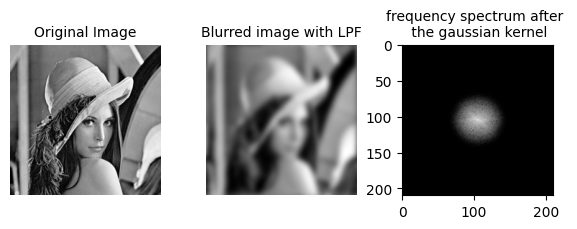

In [40]:
plt.figure(figsize=(7, 3))

plt.subplot(131)
plt.imshow(img_gry, cmap='gray')
plt.title('Original Image', size=10)
plt.axis('off')

plt.subplot(132)
plt.imshow(new_img, cmap='gray')
plt.title('Blurred image with LPF', size=10)
plt.axis('off')

plt.subplot(133)
plt.imshow(20 * np.log1p(np.abs(fp.fftshift(freq_gaussian))), cmap='gray')
plt.title('frequency spectrum after \n the gaussian kernel', size=10)
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

<div style="margin:0 130px 0 30px;text-align:justify"><p style="font-family:Source Sans Pro;font-size:20px">The code snippet below demonstrates how a low-pass filter (LPF) is applied to a grayscale image of a lenna, using various frequency cutoff values, denoted as F:</p></div>


<p style="font-family:Bookman Old Style;font-size:27px">Loading and Preprocessing the Image</p>

In [41]:
img2 = cv2.imread('../images-videos/lenna.jpg')
img_gry2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
(w, h) = img_gry2.shape
half_w = int(w / 2)
half_h = int(h / 2)
freq = fp.fft2(img_gry2)

<p style="font-family:Bookman Old Style;font-size:27px">Calculating Signal-to-Noise Ratio (SNR)</p>

In [42]:
def calculate_snr(image):
    signal = np.mean(image)  # mean of the signal
    noise = np.std(image)
    if noise != 0:
        return signal / noise
    else:
        return 0

<p style="font-family:Bookman Old Style;font-size:27px">Apply and display Low-Pass Filter and Computing SNR for Different Cut-Off Frequencies</p>

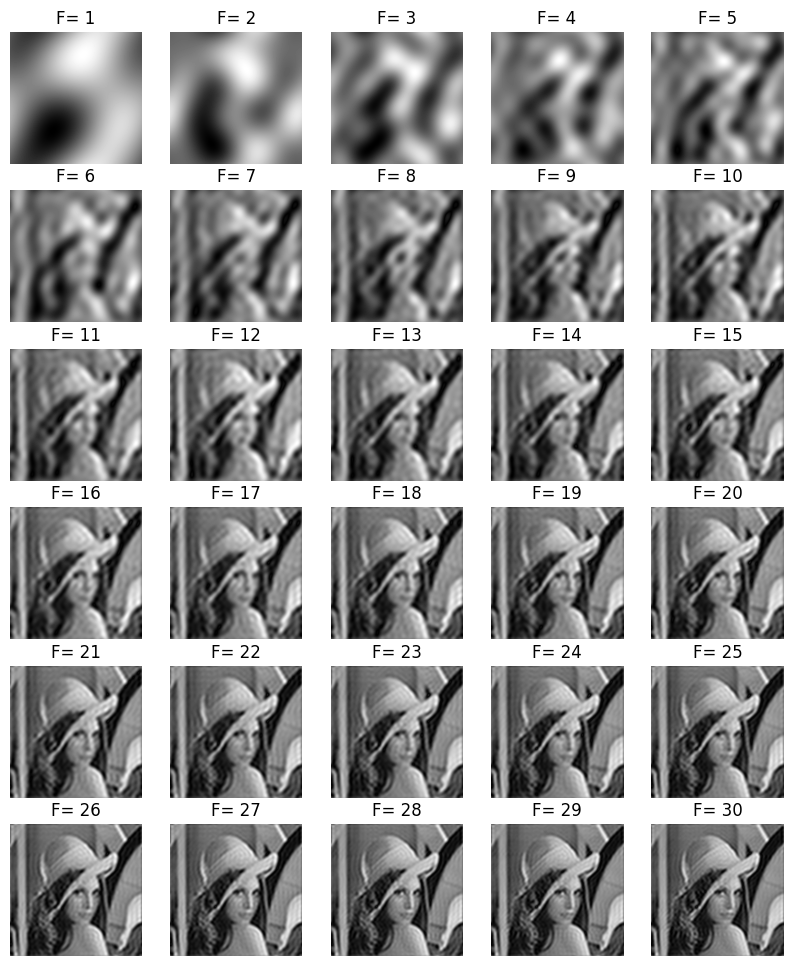

In [44]:
img_lists = list(range(1, 31))
snr_lists = []

plt.figure(figsize=(10, 12))
for i in img_lists:
    freq1 = np.copy(freq)
    shift_freq1 = fp.fftshift(freq1)
    new_shift_freq = np.copy(shift_freq1)
    shift_freq1[half_w-i:half_w+(i+1), half_h-i:half_h+(i+1)] = 0
    new_shift_freq = new_shift_freq - shift_freq1
    new_img = np.abs(fp.ifft2(new_shift_freq))
    snr_lists.append(calculate_snr(new_img))
    plt.subplot(6, 5, i)
    plt.imshow(new_img, cmap='gray')
    plt.title('F= ' + str(i))
    plt.axis('off')
plt.show()

<p style="font-family:Bookman Old Style;font-size:27px">Plotting SNR vs. Cut-Off Frequency</p>

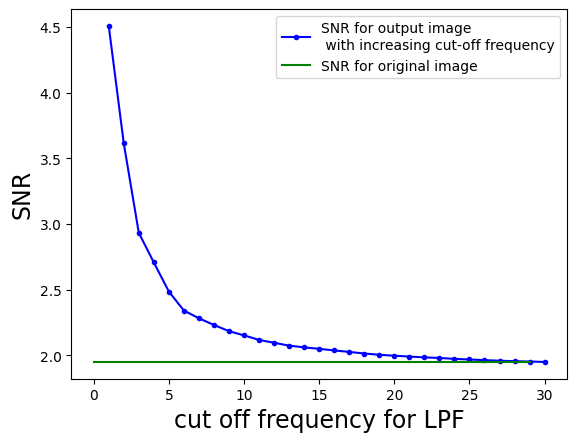

In [45]:
# all of images
plt.plot(img_lists, snr_lists, 'b.-', label='SNR for output image \n'
                                            ' with increasing cut-off frequency')
# original image
plt.plot(range(30), [snr_lists[29]]*30, 'g-', label='SNR for original image')
plt.xlabel('cut off frequency for LPF', size=17)
plt.ylabel('SNR', size=17)
plt.legend(loc='upper right', fontsize='medium')
plt.show()
